In [ ]:
from IPython.display import display, HTML
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, f1_score, roc_curve, auc

# NLP
import nltk
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')
stemmer = SnowballStemmer("english")
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import GridSearchCV
import time



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Загрузка
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates().reset_index(drop=True, inplace=True)

In [ ]:
df['tweet'].isnull().sum()

np.int64(0)

In [ ]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
# Убираем спецсимволы, чтобы посчитать статистику по словам

def deEmojify(x):
    regrex_pattern = re.compile(pattern = "^[\u203C-\u3299\U0001F000-\U0001F644]", flags = re.UNICODE)
    return regrex_pattern.sub(r'', x)

def remove_punct(text):
    text = "".join([char for char in text if char not in string.punctuation])
    text = re.sub('[0-9]+', '', text)
    text = re.sub(r"[^a-zA-Z0-9?!.,]+", ' ', text)
    return text

def basic_clean(text):
    text = str(text).lower()
    text = deEmojify(text)
    text = remove_punct(text)
    return text


In [ ]:
# Создаем временную колонку для анализа
df['temp_tweet'] = df['tweet'].apply(basic_clean)

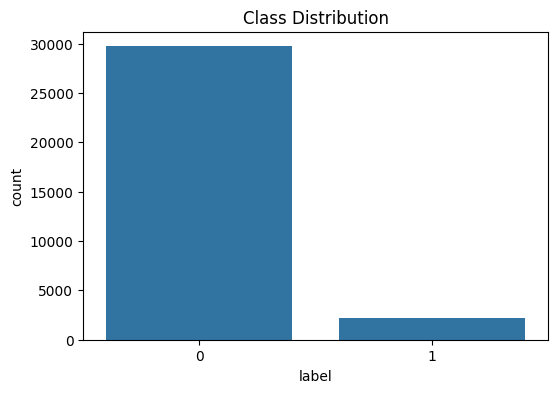

In [ ]:
# EDA
# баланс классов
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()


In [ ]:
# частотность
all_words = ' '.join([text for text in df['temp_tweet']]).split()
count_words = Counter(all_words)
common = pd.DataFrame(count_words.most_common(20), columns=['Word', 'Count'])

In [ ]:
common

,Word,Count
0,user,17509
1,the,10201
2,to,9845
3,a,6473
4,i,5793
5,you,5473
6,and,4898
7,in,4665
8,for,4498
9,is,4186


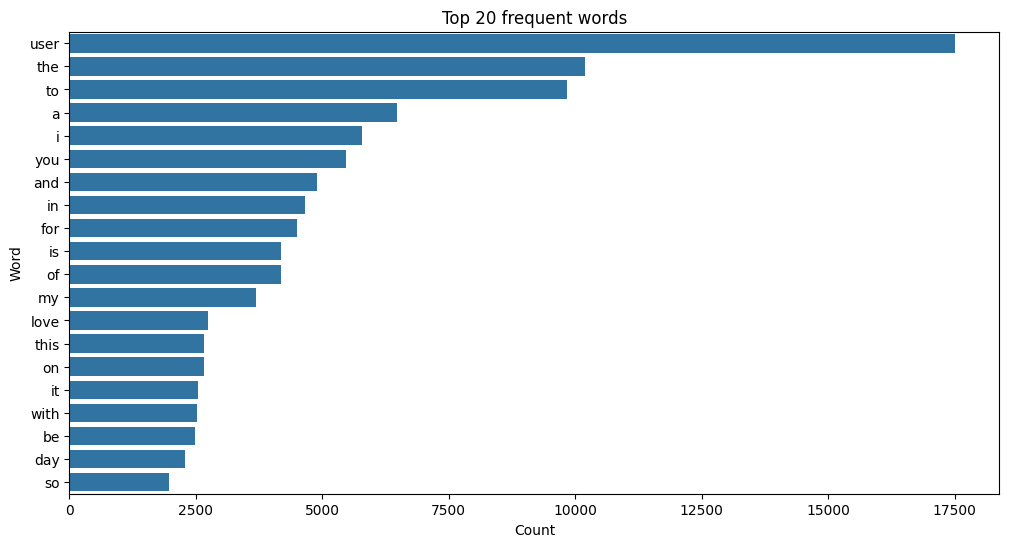

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=common)
plt.title('Top 20 frequent words')
plt.show()

In [ ]:
#редкие слова
df_words = pd.DataFrame(count_words.most_common(), columns=['Word', 'Count'])
rare_count = len(df_words[df_words['Count'] == 1])
total_count = len(df_words)


In [ ]:
total_count

39662

In [ ]:
rare_count

24688

In [ ]:
#длина твитов
df['word_count'] = df['temp_tweet'].apply(lambda x: len(str(x).split()))

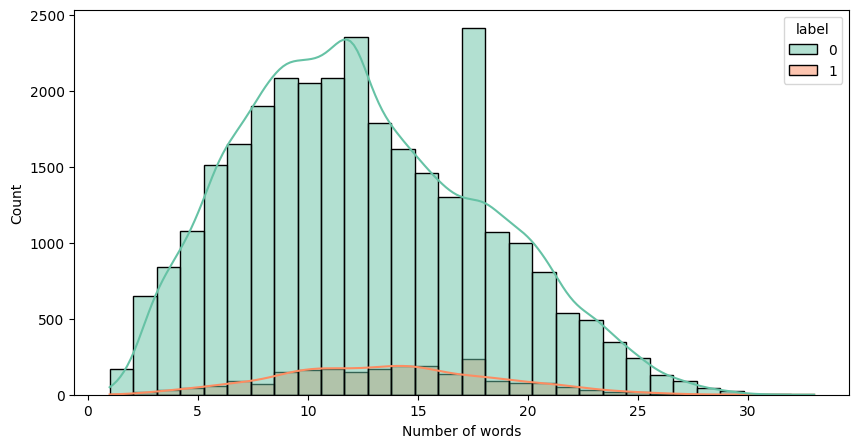

Средняя длина (0): 12.469078061911171
Средняя длина (1): 13.626226583407671


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=30, palette='Set2')
plt.xlabel('Number of words')
plt.show()

print("Средняя длина (0):", df[df['label']==0]['word_count'].mean())
print("Средняя длина (1):", df[df['label']==1]['word_count'].mean())

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
#Удаление стоп слов и самого частого слова юзер
def advanced_clean(text):
    words = text.split()
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and w != 'user']
    return " ".join(clean_words)
    # clean_words = [stemmer.stem(w) for w in words if w not in stop_words and w != 'user']
    # return " ".join(clean_words)

df['clean_tweet'] = df['temp_tweet'].apply(advanced_clean)
display(df[['temp_tweet', 'clean_tweet']].head())


,temp_tweet,clean_tweet
0,user when a father is dysfunctional and is so...,father dysfunctional selfish drag kid dysfunct...
1,user user thanks for lyft credit i cant use ca...,thanks lyft credit cant use cause dont offer w...
2,bihday your majesty,bihday majesty
3,model i love u take with u all the time in ur,model love u take u time ur
4,factsguide society now motivation,factsguide society motivation


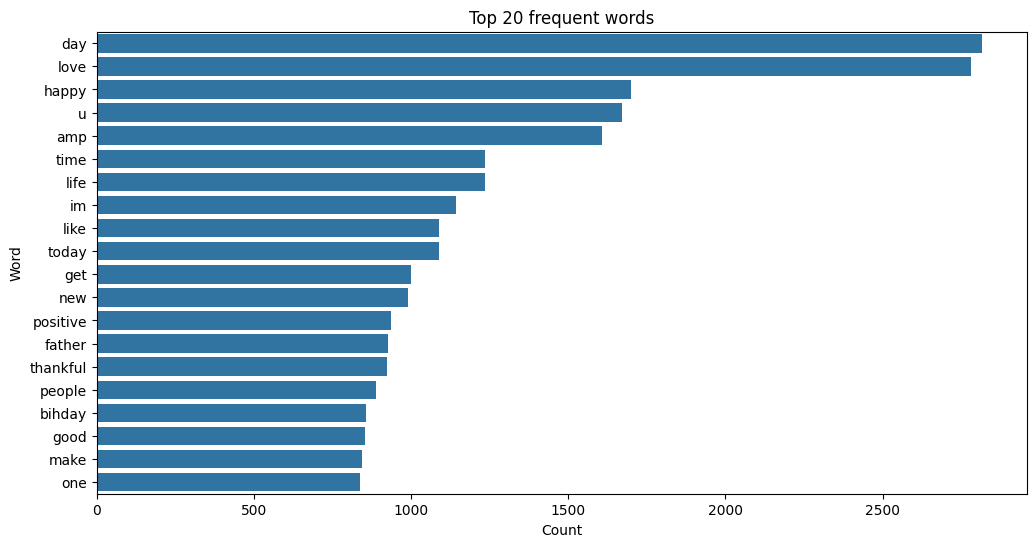

In [ ]:
all_clean_words = ' '.join([text for text in df['clean_tweet']]).split()

count_clean_words = Counter(all_clean_words)
common_clean = pd.DataFrame(count_clean_words.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=common_clean)
plt.title('Top 20 frequent words')
plt.show()

In [ ]:
X = df['clean_tweet']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:


def full_evaluation(model, name):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    acc = accuracy_score(y_test, pred_test)
    f1_test = f1_score(y_test, pred_test)
    f1_train = f1_score(y_train, pred_train)


    try:
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, probs)
        else:
            roc = roc_auc_score(y_test, pred_test)
            probs = pred_test
    except:
        roc = 0.5
        probs = pred_test

    print(f"F1 Train: {f1_train:.4f}")
    print(f"F1 Test:  {f1_test:.4f}")
    print(f"разница:      {f1_train - f1_test:.4f} ")
    print("-" * 30)
    print(classification_report(y_test, pred_test))

    fig, ax = plt.subplots(1, 2, figsize=(6, 2))
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    ax[0].plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc_val)
    ax[0].plot([0, 1], [0, 1],'r--')
    ax[0].set_title('ROC Curve')
    ax[0].legend(loc = 'lower right')

    # матрица
    sns.heatmap(confusion_matrix(y_test, pred_test, normalize='true'), annot=True, fmt='.2f', cmap='YlGnBu', ax=ax[1])
    ax[1].set_title('Confusion Matrix (Normalized)')
    plt.tight_layout()
    plt.show()
    return acc, f1_test, f1_train, roc


In [ ]:

from sklearn.preprocessing import StandardScaler
pipe1 = Pipeline([
    ('vec', CountVectorizer()),
    ('clf', ComplementNB())
])

pipe2 = Pipeline([
    ('vec', TfidfVectorizer( stop_words='english',
        use_idf=True
    )),
    ('clf', ComplementNB())
])

pipe3 = Pipeline([
    ('vec', TfidfVectorizer()),
    ('svd', TruncatedSVD(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

pipe4 = Pipeline([
    ('vec', TfidfVectorizer()),
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])





GRID SEARCH: 1. CountVectorizer + NaiveBayes
Fitting 3 folds for each of 48 candidates, totalling 144 fits
BEST PARAMS: {'clf__alpha': 0.5, 'clf__norm': True, 'vec__max_features': 30000, 'vec__min_df': 1}
F1 Train: 0.8265
F1 Test:  0.6725
разница:      0.1540 
------------------------------
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5945
           1       0.77      0.60      0.67       448

    accuracy                           0.96      6393
   macro avg       0.87      0.79      0.83      6393
weighted avg       0.96      0.96      0.96      6393



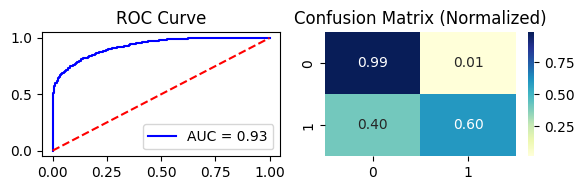


 GRID SEARCH: 2. TF-IDF + NaiveBayes
Fitting 3 folds for each of 48 candidates, totalling 144 fits
BEST PARAMS: {'clf__alpha': 0.8, 'vec__max_features': 20000, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
F1 Train: 0.6567
F1 Test:  0.6176
разница:      0.0390 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5945
           1       0.55      0.71      0.62       448

    accuracy                           0.94      6393
   macro avg       0.76      0.83      0.79      6393
weighted avg       0.95      0.94      0.94      6393



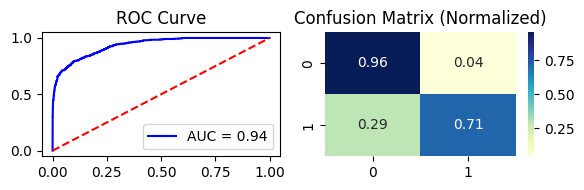


 GRID SEARCH: 3. TF-IDF + SVD + LogReg
Fitting 3 folds for each of 16 candidates, totalling 48 fits
BEST PARAMS: {'clf__C': 10, 'clf__penalty': 'l2', 'svd__n_components': 200, 'vec__max_features': 25000}
F1 Train: 0.3821
F1 Test:  0.3864
разница:      -0.0043 
------------------------------
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      5945
           1       0.25      0.85      0.39       448

    accuracy                           0.81      6393
   macro avg       0.62      0.83      0.64      6393
weighted avg       0.93      0.81      0.85      6393



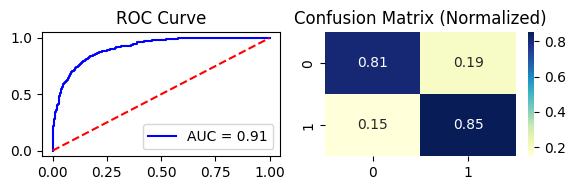


GRID SEARCH: 4. TF-IDF + LogReg (без SVD)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
BEST PARAMS: {'clf__C': 1, 'clf__penalty': 'l2', 'vec__max_features': 10000, 'vec__min_df': 5, 'vec__ngram_range': (1, 2)}
F1 Train: 0.7361
F1 Test:  0.5985
разница:      0.1376 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      5945
           1       0.49      0.78      0.60       448

    accuracy                           0.93      6393
   macro avg       0.73      0.86      0.78      6393
weighted avg       0.95      0.93      0.93      6393



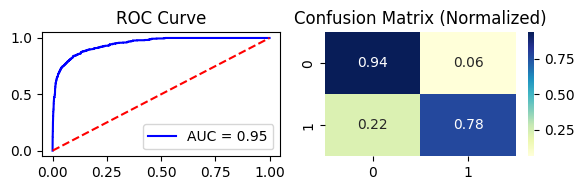

Время выполнения:  6.50 минут


In [ ]:
from sklearn.model_selection import GridSearchCV
import time

start_time = time.time()

#1 CountVectorizer + NaiveBayes

print("\n" + "="*40)
print("GRID SEARCH: 1. CountVectorizer + NaiveBayes")
print("="*40)

param_grid_1 = {
    'vec__max_features': [10000, 20000, 30000],
    'vec__min_df': [1, 5],
    'clf__alpha': [0.5, 0.8, 1.0, 1.5],
    'clf__norm': [False, True]
}


grid_1 = GridSearchCV(pipe1, param_grid_1, cv=3, scoring='f1', verbose=1, n_jobs=-1)
grid_1.fit(X_train, y_train)

print(f"BEST PARAMS: {grid_1.best_params_}")
acc1, f1_1, f1_tr1, roc1 = full_evaluation(grid_1.best_estimator_, "GRID: CountVec + NB")


#2 TF-IDF + NaiveBayes

print("\n" + "="*40)
print(" GRID SEARCH: 2. TF-IDF + NaiveBayes")
print("="*40)

param_grid_2 = {
    'vec__max_features': [20000, 30000, 50000],
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__min_df': [2, 5],
    'clf__alpha': [0.5, 0.8, 1.0, 1.2]
}

grid_2 = GridSearchCV(pipe2, param_grid_2, cv=3, scoring='f1', verbose=1, n_jobs=-1)
grid_2.fit(X_train, y_train)

print(f"BEST PARAMS: {grid_2.best_params_}")
acc2, f1_2,f1_tr2, roc2 = full_evaluation(grid_2.best_estimator_, "GRID: TF-IDF + NB")



#3 TF-IDF + SVD + LogReg

print("\n" + "="*40)
print(" GRID SEARCH: 3. TF-IDF + SVD + LogReg")
print("="*40)

param_grid_3 = {
    'vec__max_features': [15000, 25000],
    'svd__n_components': [100, 200],
    'clf__C': [0.1, 1, 1.5, 10],
    'clf__penalty': ['l2']
}

grid_3 = GridSearchCV(pipe3, param_grid_3, cv=3, scoring='f1', verbose=1, n_jobs=-1)
grid_3.fit(X_train, y_train)

print(f"BEST PARAMS: {grid_3.best_params_}")
acc3, f1_3, f1_tr3, roc3 = full_evaluation(grid_3.best_estimator_, "GRID: SVD + LogReg")



#4 TF-IDF + BIGRAMS + LogReg (без SVD)
print("\n" + "="*40)
print("GRID SEARCH: 4. TF-IDF + LogReg (без SVD)")
print("="*40)

param_grid_4 = {
    'vec__max_features': [10000, 20000, 30000],
    'vec__ngram_range': [(1, 2)],
    'vec__min_df': [ 5, 10],
    'clf__C': [0.1, 1],
    'clf__penalty': ['l2']
}

grid_4 = GridSearchCV(pipe4, param_grid_4, cv=3, scoring='f1', verbose=1, n_jobs=-1)
grid_4.fit(X_train, y_train)

print(f"BEST PARAMS: {grid_4.best_params_}")
acc4, f1_4, f1_tr4, roc4 = full_evaluation(grid_4.best_estimator_, "GRID: LogReg без SVD")

end_time = time.time()
duration = end_time - start_time
print(f"Время выполнения:  {duration/60:.2f} минут")

F1 Train: 0.7256
F1 Test:  0.6396
разница:      0.0861 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      5945
           1       0.55      0.77      0.64       448

    accuracy                           0.94      6393
   macro avg       0.76      0.86      0.80      6393
weighted avg       0.95      0.94      0.94      6393



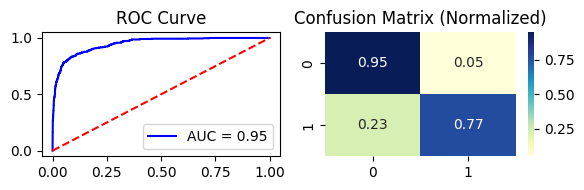

In [ ]:
#настройка вручную , что бы откалибровать переобучение
pipe_final_test = Pipeline([
    ('vec', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        stop_words='english',
        sublinear_tf=True,
        use_idf=True,
        min_df=4)),
     ('scaler', MaxAbsScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        C=0.08,
        solver='liblinear',
        random_state=42))
])

results = full_evaluation(pipe_final_test, "log reg")

F1 Train: 0.6950
F1 Test:  0.6424
разница:      0.0526 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      5945
           1       0.60      0.69      0.64       448

    accuracy                           0.95      6393
   macro avg       0.79      0.83      0.81      6393
weighted avg       0.95      0.95      0.95      6393



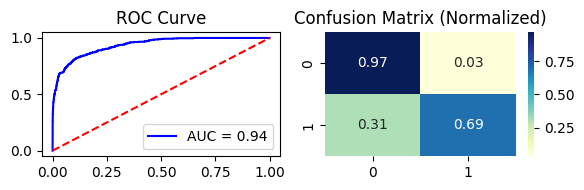

(0.9461911465665571,
 0.6424116424116424,
 0.6950319724545008,
 np.float64(0.9356945737714766))

In [ ]:
#ComplementNB
pipe_nb_manual = Pipeline([
    ('vec', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        #stop_words='english',
        sublinear_tf=True,
        min_df=5,
        use_idf=True)),
    ('clf', ComplementNB(
        alpha=1.1,
        norm=True
    ))
])

full_evaluation(pipe_nb_manual, "complementNB")

F1 Train: 0.7497
F1 Test:  0.6667
разница:      0.0830 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5945
           1       0.60      0.75      0.67       448

    accuracy                           0.95      6393
   macro avg       0.79      0.86      0.82      6393
weighted avg       0.95      0.95      0.95      6393



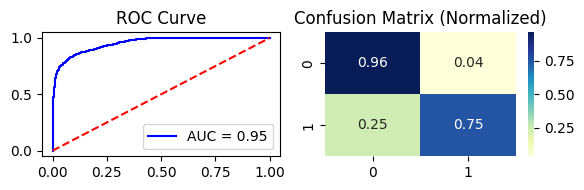

(0.9471296730799311,
 0.6666666666666666,
 0.7496665184526456,
 np.float64(0.9519126216508469))

In [ ]:
from sklearn.ensemble import VotingClassifier

#хотелоcь попробовать ансабль, действительно ли дает прирост в метрике
best_nb = grid_2.best_estimator_
best_lr = grid_4.best_estimator_

ensemble = VotingClassifier(
    estimators=[('nb', best_nb), ('lr', best_lr)],
    voting='soft'
)

full_evaluation(ensemble, "Ensemble")

F1 Train: 0.7246
F1 Test:  0.5581
разница:      0.1665 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      5945
           1       0.45      0.73      0.56       448

    accuracy                           0.92      6393
   macro avg       0.71      0.83      0.76      6393
weighted avg       0.94      0.92      0.93      6393



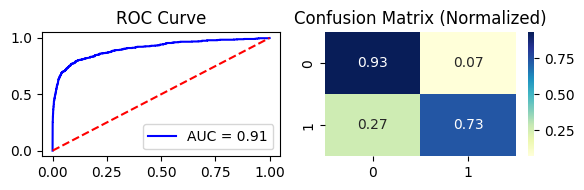

(0.9185046144220241,
 0.5581000848176421,
 0.7246376811594203,
 np.float64(0.9071612549561456))

In [ ]:
from sklearn.preprocessing import StandardScaler
# Пробую svd для логрег
pipe_svd_final = Pipeline([
    ('vec', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=40000,
        stop_words='english',
        min_df=5,
        use_idf=True)),
    ('svd', TruncatedSVD(
        n_components=2000,
        random_state=42)),
     ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        C=0.05,
        solver='liblinear',
        random_state=42))
])

full_evaluation(pipe_svd_final, "SVD_LogReg")

F1 Train: 0.7336
F1 Test:  0.6393
разница:      0.0943 
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      5945
           1       0.55      0.76      0.64       448

    accuracy                           0.94      6393
   macro avg       0.77      0.86      0.80      6393
weighted avg       0.95      0.94      0.94      6393



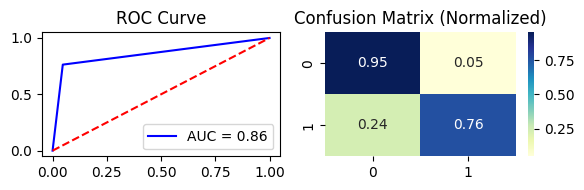

(0.9396214609729392,
 0.6392523364485981,
 0.7335593220338983,
 np.float64(0.8581472275621771))

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MaxAbsScaler
pipe_svd_svm = Pipeline([
    ('vec', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=4,
        sublinear_tf=True,
        stop_words='english'
    )),
   # ('svd', TruncatedSVD(n_components=800, random_state=42)),
    ('scaler', MaxAbsScaler()),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, C=0.01))
])
full_evaluation(pipe_svd_svm, "SVD_SVM_Model")

Использовала классические модели мл (Naive Bayes, Logistic Regression) с различными методами предобработки текста (стемминг, лемматизация, TF-IDF).
 Несмотря на высокий потенциал LogReg (F1 до 0.68), модель показала склонность к переобучению (разница между трейном и тестом достигала 0.18–0.23).
 Линейные модели слишком сильно подстраивались под слова в обучающей выборке, что делало их нестабильными для реальных данных.
Использование понижения размерности полностью провалилось (F1 упал до 0.42). Сжатие признаков размывает маркеры негативных твиттов, которые критически важны для классификации коротких твитов.
Проболвала с понижением размерности лог регрессию, но даже со стандартизацией и кол-вом компонентов в 2000 дало всего F1 Test:  0.5581. (больше не стала увеличивать, очень долго крутит). Так же пробовала lenearSVC, без понижения размерности дало больший F1, но все равно не дотягивает по балансу до наивного байеса для несбалансированных данных.
Из всех вариантов связка TF-IDF + ComplementNB показала наилучший баланс, но без исключения стоп слов.
Лемматизация показала прирост 1-2% по сравнению со стеммингом.
Результаты финальной модели:
F1 на тесте  0.6417,
Разница между трейном и тестом всего 0.0541,
Recall: 0.69 (модель находит почти 70% всего токсичного контента),
Выбрана  модель, которая обеспечивает максимальную надежность при более высокой метрике F1.
Разница между обучением и тестом в 5% гарантирует, что на новых, реальных твитах модель сработает так же хорошо, как и на тестах